In [1]:
import os
os.environ['KERAS_BACKEND'] = 'torch'

In [2]:
import cv2
import torch
import numpy as np
import pandas as pd
import transformers
import sklearn.manifold
import sklearn.decomposition
import tqdm.notebook as tqdm
import sklearn.model_selection
import matplotlib.pyplot as plt
from typing import Literal
import tables
import PIL.Image
import keras

In [3]:
processor = transformers.AutoImageProcessor.from_pretrained('facebook/dinov2-base', use_fast=True)
backbone = transformers.AutoModel.from_pretrained('facebook/dinov2-base')

# processor = transformers.AutoImageProcessor.from_pretrained('facebook/dinov3-vitb16-pretrain-lvd1689m')
# backbone = transformers.AutoModel.from_pretrained('facebook/dinov3-vitb16-pretrain-lvd1689m')

# processor = transformers.AutoImageProcessor.from_pretrained('facebook/dinov3-convnext-base-pretrain-lvd1689m')
# backbone = transformers.AutoModel.from_pretrained('facebook/dinov3-convnext-base-pretrain-lvd1689m')

2025-10-20 18:09:37.988576: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-10-20 18:09:38.017816: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX_VNNI, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [4]:
data = pd.read_csv("dogs.csv")

In [5]:
data

,filepaths,labels,data set
0,train/Afghan/001.jpg,Afghan,train
1,train/Afghan/002.jpg,Afghan,train
2,train/Afghan/003.jpg,Afghan,train
3,train/Afghan/004.jpg,Afghan,train
4,train/Afghan/005.jpg,Afghan,train
...,...,...,...
9341,valid/Yorkie/06.jpg,Yorkie,valid
9342,valid/Yorkie/07.jpg,Yorkie,valid
9343,valid/Yorkie/08.jpg,Yorkie,valid
9344,valid/Yorkie/09.jpg,Yorkie,valid


In [6]:
data.labels.value_counts()

labels
Shih-Tzu             218
Lhasa                207
Labrador             181
Basset               179
Scotch Terrier       170
                    ... 
Yorkie                98
Saint Bernard         98
Newfoundland          98
American Hairless     85
American  Spaniel     10
Name: count, Length: 71, dtype: int64

In [7]:
set(data[data['data set'] == 'train'].labels.unique())^set(data[data['data set'] == 'valid'].labels.unique())

{'American  Spaniel', 'American Spaniel'}

In [8]:
data.loc[data.labels == 'American  Spaniel', 'labels'] = 'American Spaniel'

In [9]:
data[data.labels == 'American Spaniel'].labels

396     American Spaniel
397     American Spaniel
398     American Spaniel
399     American Spaniel
400     American Spaniel
              ...       
8681    American Spaniel
8682    American Spaniel
8683    American Spaniel
8684    American Spaniel
8685    American Spaniel
Name: labels, Length: 109, dtype: object

In [10]:
encoder = sklearn.preprocessing.LabelEncoder().fit(data.labels)

In [11]:
data['class'] = encoder.transform(data.labels)

In [12]:
backbone

Dinov2Model(
  (embeddings): Dinov2Embeddings(
    (patch_embeddings): Dinov2PatchEmbeddings(
      (projection): Conv2d(3, 768, kernel_size=(14, 14), stride=(14, 14))
    )
    (dropout): Dropout(p=0.0, inplace=False)
  )
  (encoder): Dinov2Encoder(
    (layer): ModuleList(
      (0-11): 12 x Dinov2Layer(
        (norm1): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
        (attention): Dinov2Attention(
          (attention): Dinov2SelfAttention(
            (query): Linear(in_features=768, out_features=768, bias=True)
            (key): Linear(in_features=768, out_features=768, bias=True)
            (value): Linear(in_features=768, out_features=768, bias=True)
          )
          (output): Dinov2SelfOutput(
            (dense): Linear(in_features=768, out_features=768, bias=True)
            (dropout): Dropout(p=0.0, inplace=False)
          )
        )
        (layer_scale1): Dinov2LayerScale()
        (drop_path): Identity()
        (norm2): LayerNorm((768,), eps=1e-06,

In [13]:
filters = tables.Filters(3, "blosc:lz4")

In [14]:
backbone = backbone.cuda()

In [15]:
def predata(data: pd.DataFrame, path: str, split: Literal['train', 'valid'], batch_size: int = 16):
    data = data[data['data set'] == split]
    with tables.open_file(path, "w") as file, torch.no_grad():
        array = file.create_carray(file.root, "embeddings", tables.Float32Atom(), shape=(len(data), 768), filters=filters)
        answers = file.create_carray(file.root, "label", tables.Int8Atom(), shape=(len(data),), filters=filters)
    
        for i in tqdm.trange(0, len(data), batch_size):
            image_paths = data['filepaths'].iloc[i:i + batch_size]
            images = [PIL.Image.open(path).convert('RGB') for path in image_paths]
            images = processor(images, return_tensors='pt').to(backbone.device)
            features = backbone(**images).pooler_output.cpu().numpy()
            array[i:i + batch_size] = features
            answers[i:i + batch_size] = data['class'].iloc[i:i + batch_size].to_numpy()
            
    
    

In [61]:
predata(data, 'dogs_train.hdf5', 'train')

  0%|          | 0/497 [00:00<?, ?it/s]

In [62]:
predata(data, 'dogs_valid.hdf5', 'valid')

  0%|          | 0/44 [00:00<?, ?it/s]

In [16]:
train_file, test_file = tables.open_file("dogs_train.hdf5", "r"), tables.open_file("dogs_valid.hdf5", "r")

In [17]:
train_file.root.embeddings

/embeddings (CArray(7946, 768)shuffle, blosc:lz4(3)) ''
  atom := Float32Atom(shape=(), dflt=0.0)
  maindim := 0
  flavor := 'numpy'
  byteorder := 'little'
  chunkshape := (42, 768)

In [18]:
class Datasett(keras.utils.PyDataset):
    def __init__(self, dataset: tables.File, batch_size: int = 64, shuffle: bool = False, **kwargs):
        super().__init__(**kwargs)
        self.dataset = dataset
        self.batch_size = batch_size
        self.shuffle = shuffle
        self.rng = np.random.default_rng()

        self.idx = np.arange(len(self.dataset.root["label"]))

        self.on_epoch_end()

    def __len__(self) -> int:
        return (self.idx.shape[0] + self.batch_size - 1) // self.batch_size
    
    def __getitem__(self, idx: int) -> tuple[np.ndarray, np.ndarray]:
        beg_ind = idx * self.batch_size
        end_ind = (idx + 1) * self.batch_size
    
        idx = self.idx[beg_ind:end_ind]

        return self.dataset.root["embeddings"][idx, :], self.dataset.root["label"][idx]

    def on_epoch_end(self) -> None:
        if self.shuffle:
            self.idx = self.rng.choice(self.idx, size=len(self.idx), replace=False)
        
        

In [19]:
train_datasett = Datasett(
    train_file, 
    shuffle=True,
)

test_datasett = Datasett(
    test_file, 
)

In [21]:
inputs = keras.layers.Input((768,), name="input")
x = keras.layers.Dense(70, name="output")(inputs)

model = keras.Model(inputs=inputs, outputs=x, name="model")

In [22]:
model.compile(
    optimizer="adam",
    metrics=["accuracy"],
    loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True)
)

In [23]:
model.fit(
    train_datasett,
    validation_data=test_datasett,
    epochs=10
)

Epoch 1/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7804 - loss: 0.9614 - val_accuracy: 0.9457 - val_loss: 0.1655
Epoch 2/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9371 - loss: 0.2143 - val_accuracy: 0.9643 - val_loss: 0.1291
Epoch 3/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9585 - loss: 0.1411 - val_accuracy: 0.9600 - val_loss: 0.1026
Epoch 4/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9665 - loss: 0.1040 - val_accuracy: 0.9586 - val_loss: 0.1140
Epoch 5/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9755 - loss: 0.0778 - val_accuracy: 0.9729 - val_loss: 0.0773
Epoch 6/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9787 - loss: 0.0650 - val_accuracy: 0.9686 - val_loss: 0.1000
Epoch 7/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9855 - loss: 0.0488 - val_accuracy: 0.9714 - val_loss: 0.0920
Epoch 8/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9892 - loss: 0.0385 - val_accuracy: 0.

In [42]:
y_pred = model.predict(test_file.root["embeddings"][:], verbose=False).argmax(axis=-1)
y_true = test_file.root["label"][:]

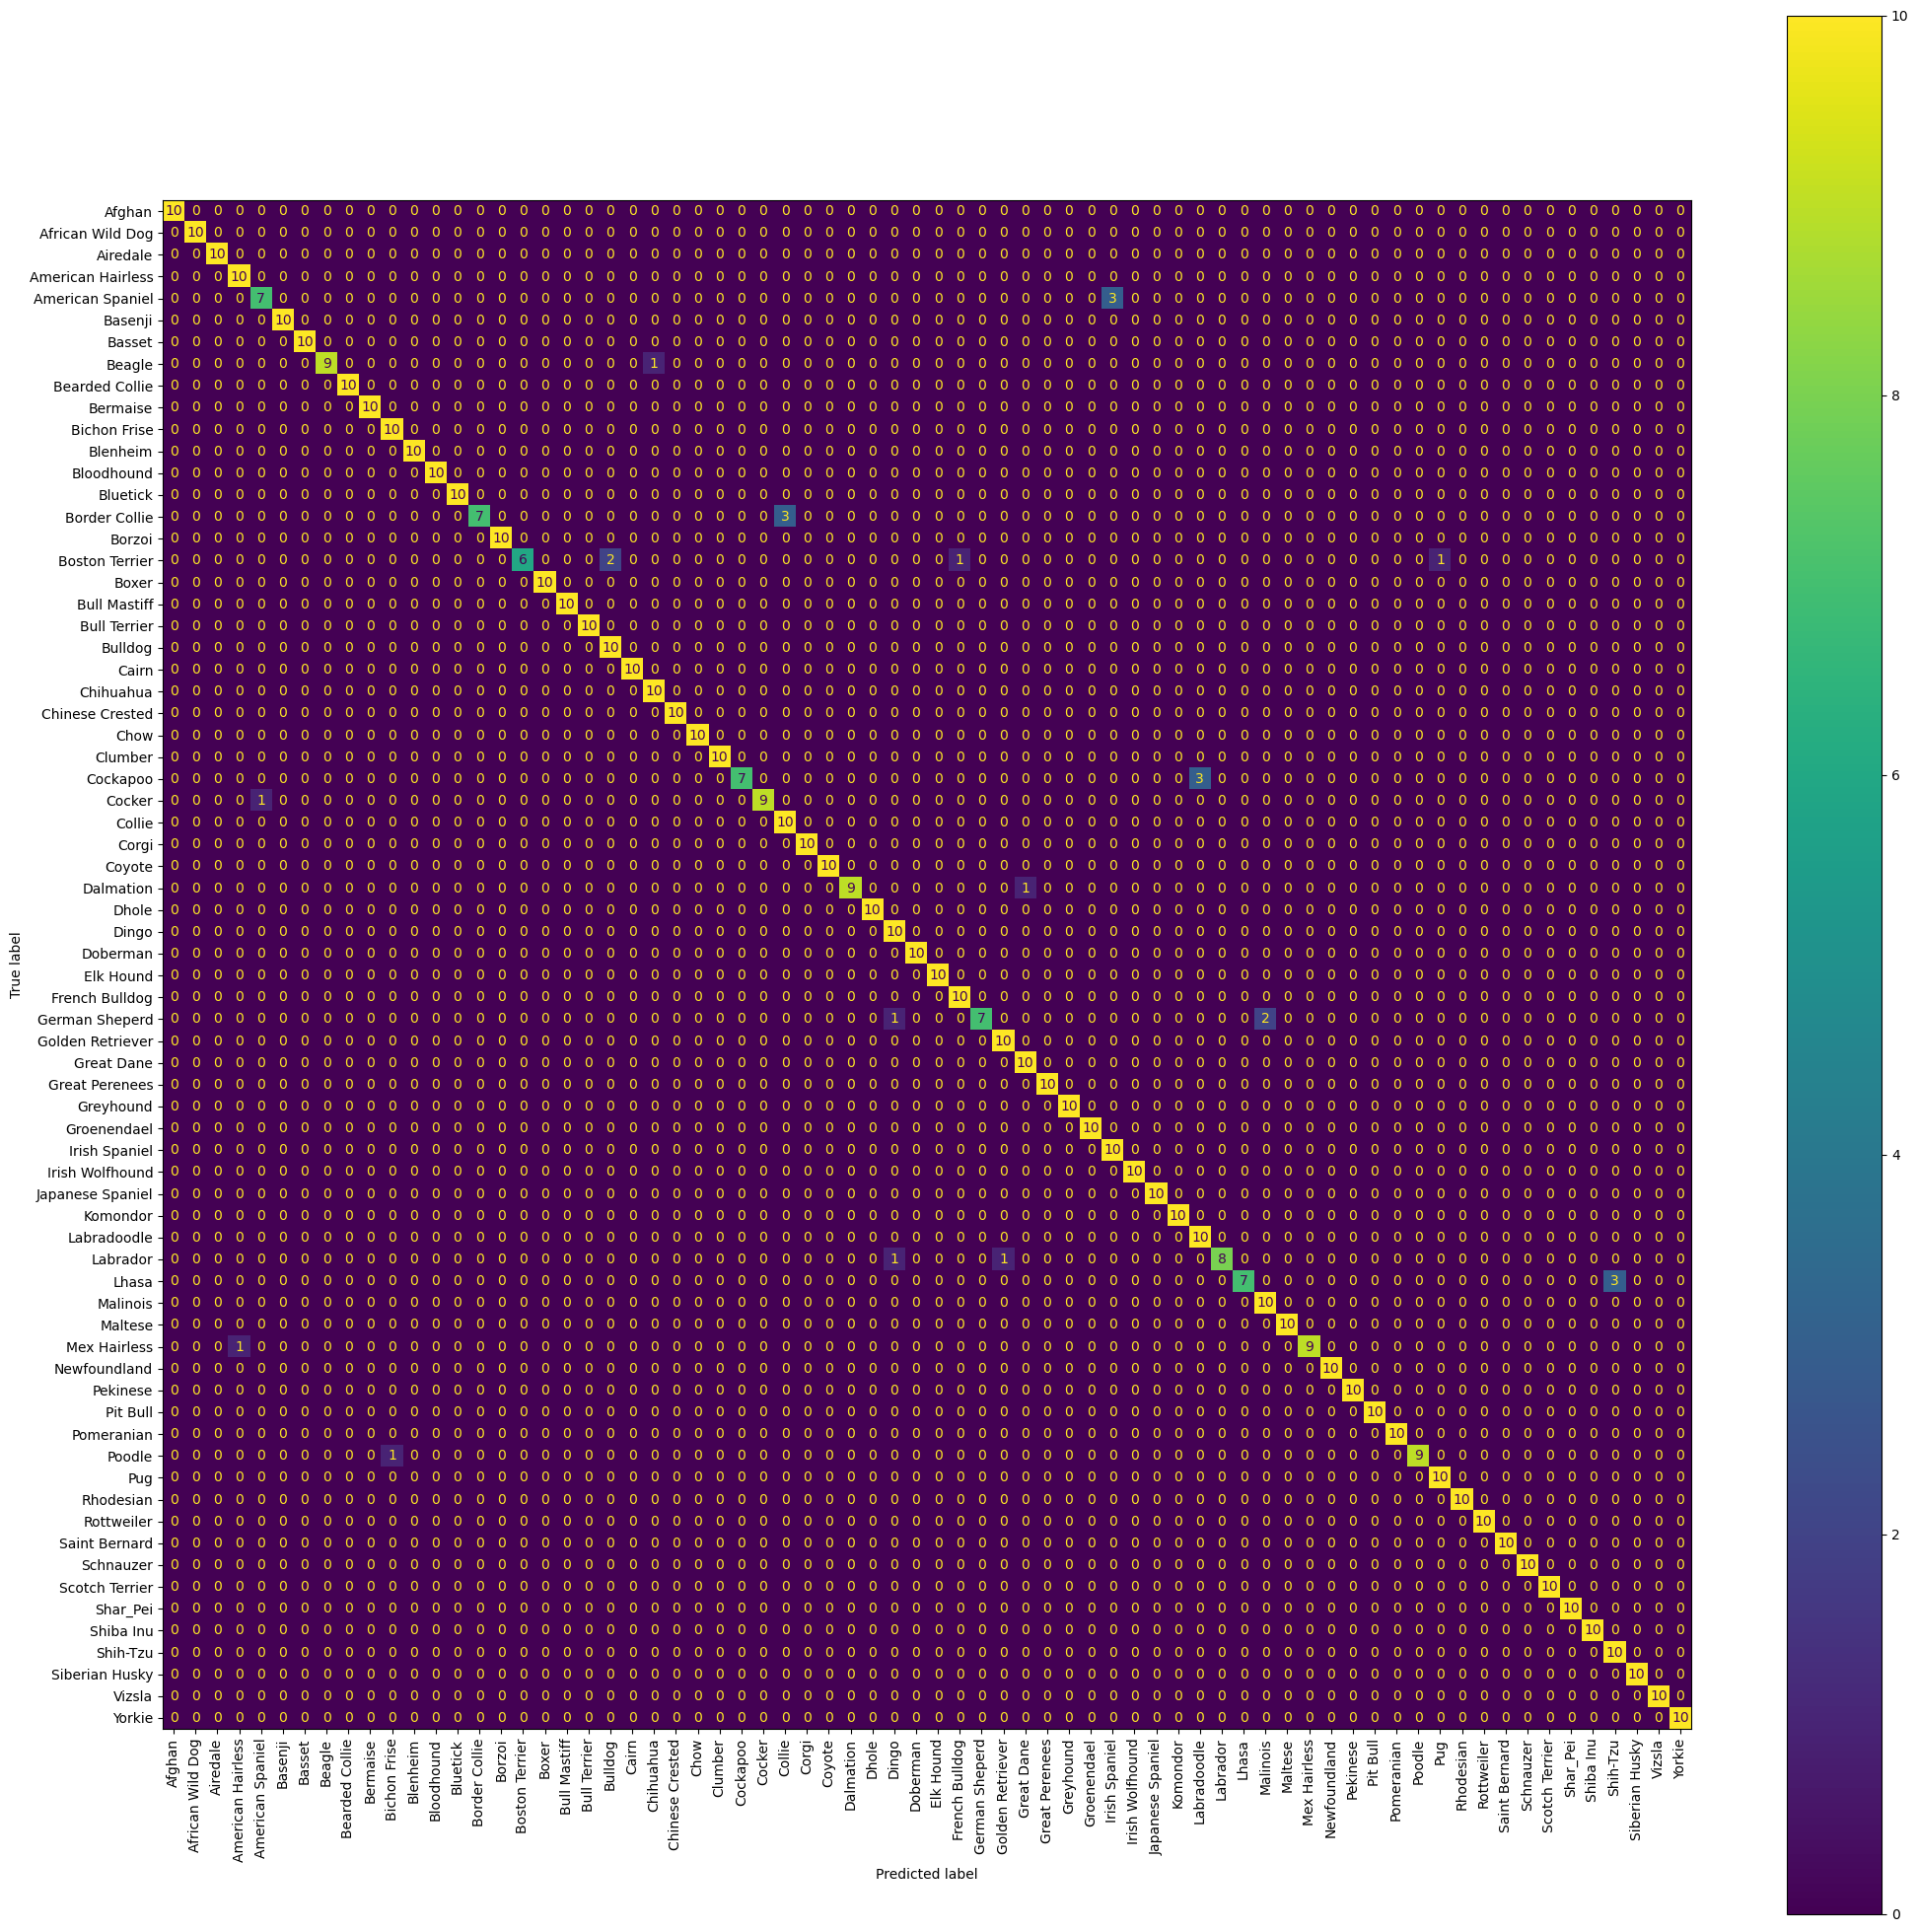

In [43]:
_, ax = plt.subplots(figsize=(25, 25))
sklearn.metrics.ConfusionMatrixDisplay.from_predictions(
    y_true,
    y_pred,
    ax=ax,
    xticks_rotation=90,
    display_labels=encoder.classes_
)

plt.savefig('1.png')

In [47]:
def scale(data):
    return np.array([
        (i - data.min()) / (data.max() - data.min())
        for i in data
    ])

In [57]:
def plot_thing(data: pd.DataFrame, processor, backone, n_classes: int, n_images_per_class: int, threshold: float = 1, batch_size: int = 8, image_size: int = 1024, use_tsne: bool = True):
    rng = np.random.default_rng()

    old_image_size = processor.size['shortest_edge']
    processor.crop_size['height'] = processor.crop_size['width'] = image_size
    processor.size['shortest_edge'] = image_size

    classes = rng.choice(data.labels.unique(), replace=False, size=n_classes)
    images = np.array([cv2.cvtColor(cv2.imread(j), cv2.COLOR_BGR2RGB) for i in classes for j in rng.choice(data.filepaths[data.labels == i], size=n_images_per_class, replace=False)])

    img = processor(images, return_tensors='pt')
    img = img['pixel_values'].cuda()

    with torch.no_grad():
        n_batches = (img.shape[0] + batch_size - 1) // batch_size
        features = np.concatenate([backbone(img[i * batch_size:(i + 1) * batch_size]).last_hidden_state.cpu().numpy()[:, 1:] for i in tqdm.trange(n_batches)], axis=0)

    del img

    n = int(np.sqrt(features.shape[1]))

    if use_tsne:
        features = scale(sklearn.manifold.TSNE(n_components=3).fit_transform(features.reshape(-1, features.shape[-1])).reshape(-1, n, n, 3))
    else:
        features = scale(sklearn.decomposition.PCA(n_components=3).fit_transform(features.reshape(-1, features.shape[-1])).reshape(-1, n, n, 3))

    processor.do_rescale = False
    processor.do_normalize = False
    images = processor(images=images, return_tensors='np')['pixel_values'].transpose(0, 2, 3, 1)
    processor.do_rescale = True
    processor.do_normalize = True

    processor.crop_size['height'] = processor.crop_size['width'] = old_image_size
    processor.size['shortest_edge'] = old_image_size

    _, ax = plt.subplots(ncols=n_classes * 2, nrows=n_images_per_class, figsize=(10 * n_classes, 5 * n_images_per_class))
    
    mask = features[..., 0] <= threshold
    features = np.where(mask[..., None], features, 0.)

    features = features.reshape(n_classes, n_images_per_class, n, n, 3)
    images = images.reshape(n_classes, n_images_per_class, *images.shape[1:3], 3)

    for i in range(n_classes):
        for j in range(n_images_per_class):
            ax[j, 2 * i].imshow(images[i, j])
            ax[j, 2 * i].axis('off')
            
            ax[j, 2 * i + 1].imshow(features[i, j])
            ax[j, 2 * i + 1].axis('off')

        ax[0, 2 * i].set_title(classes[i])

    plt.tight_layout()

In [58]:
processor = transformers.AutoImageProcessor.from_pretrained('facebook/dinov2-base')

  0%|          | 0/3 [00:00<?, ?it/s]

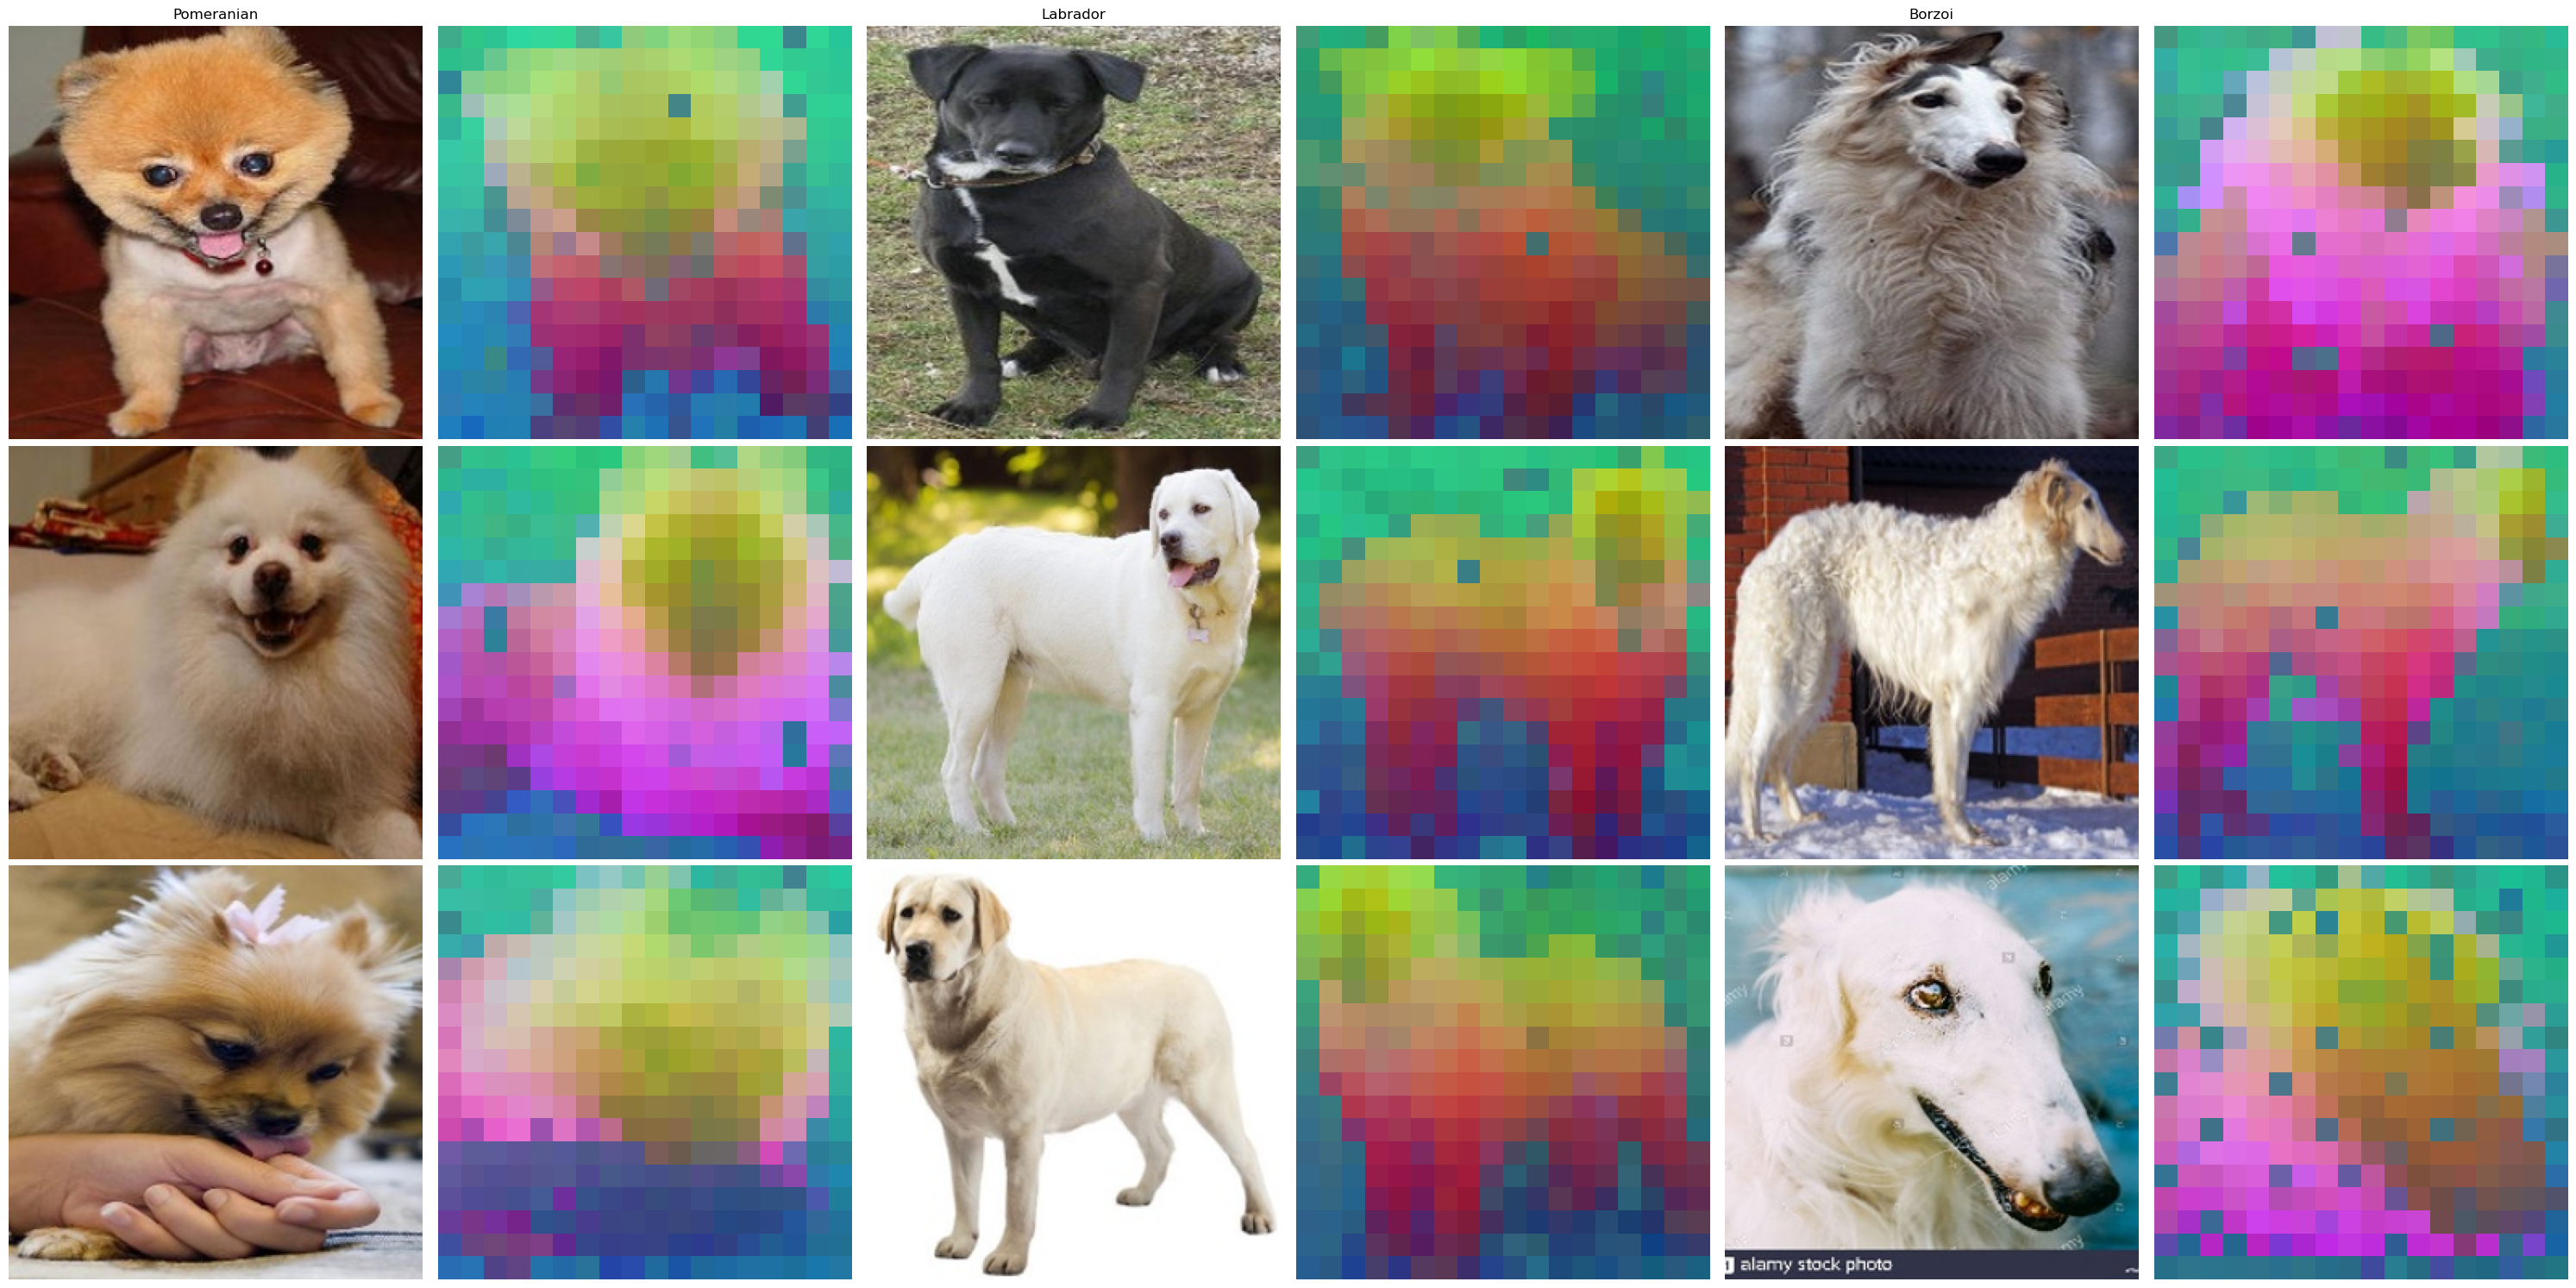

In [66]:
plot_thing(data, processor, backbone, 3, 3, threshold=1, batch_size=4, use_tsne=False, image_size=256)

In [45]:
data

,filepaths,labels,data set,class
0,train/Afghan/001.jpg,Afghan,train,0
1,train/Afghan/002.jpg,Afghan,train,0
2,train/Afghan/003.jpg,Afghan,train,0
3,train/Afghan/004.jpg,Afghan,train,0
4,train/Afghan/005.jpg,Afghan,train,0
...,...,...,...,...
9341,valid/Yorkie/06.jpg,Yorkie,valid,69
9342,valid/Yorkie/07.jpg,Yorkie,valid,69
9343,valid/Yorkie/08.jpg,Yorkie,valid,69
9344,valid/Yorkie/09.jpg,Yorkie,valid,69
